# Imports

In [1]:
!pip install numpy==2.1.3

In [2]:
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
import seaborn as sns
from statsmodels.nonparametric.kernel_regression import KernelReg
import gudhi as gd
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

# Tools

## Persistence

In [3]:
def compute_persistence_diagram(X, max_dimension=2, max_edge_length=float('inf')):
    rips_complex = gd.RipsComplex(points=X, max_edge_length=max_edge_length)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=max_dimension)
    persistence = simplex_tree.persistence()
    return persistence, simplex_tree

In [4]:
def persistence_to_df(persistence):
    df = defaultdict(list)
    for dim, (birth, death) in persistence:
        df['dim'].append(dim)
        df['birth'].append(birth)
        df['death'].append(death)
    df = pd.DataFrame.from_dict(df)
    df['lt'] = df['death'] - df['birth']
    return df

In [5]:
def plot_persistence(X, y, max_dimension, max_edge_length, labels=None):
    uy = np.unique(y)
    res = {}
    fig, ax = plt.subplots(len(uy), 2, figsize=(20, 7 * len(uy)))
    if len(ax.shape) == 1:
        ax = np.array([ax])
    for i, c in enumerate(uy):
        label = c if labels is None else labels[c]
        if callable(max_edge_length):
            mel = max_edge_length(X[y==c])
        else:
            mel = max_edge_length
        persistence, simplex_tree = compute_persistence_diagram(
            X[y==c],
            max_dimension=max_dimension,
            max_edge_length=mel,
        )
        res[c] = [persistence_to_df(persistence), simplex_tree]

        gd.plot_persistence_diagram(persistence, axes=ax[i, 0])
        gd.plot_persistence_barcode(persistence, axes=ax[i, 1]);
    return res, fig, ax

In [6]:
def compute_persistence_distance(persistence_dict):
    uy = np.unique(list(persistence_dict.keys()))
    assert np.all(uy == np.arange(0, len(uy)))
    res = np.zeros((len(uy), len(uy)))
    for i in uy:
        for j in uy:
            if i == j:
                continue
            res[i][j] = gd.bottleneck_distance(
                persistence_dict[i][['birth', 'death']].replace(np.inf, np.nan).dropna(),
                persistence_dict[j][['birth', 'death']].replace(np.inf, np.nan).dropna(),
            )
    return res

## Разное

In [7]:
def is_iterable(obj):
    try:
        iter(obj)
        return True
    except TypeError:
        return False

In [8]:
def plot_distance_hists(X, y, labels=None):
    uy = np.unique(y)
    fig, axes = plt.subplots(1, len(uy), figsize=(20, 7))
    if not is_iterable(axes):
        axes = np.array([axes])
    for i, (c, ax) in enumerate(zip(uy, axes.ravel())):
        label = c if labels is None else labels[c]
        dm = distance_matrix(X[y==c], X[y==c])
        distances = dm[np.tril_indices(dm.shape[0], k=-1)]
        sns.histplot(distances, ax=ax)
        ax.set_title(label)
        ax.set_xlabel('point distance')
    return fig, ax

In [9]:
def normalize_distances(X, y):
    X_norm = X.copy()
    uy = np.unique(y)
    for c in uy:
        dm = distance_matrix(X_norm[y == c], X_norm[y == c])
        distances = dm[np.tril_indices(dm.shape[0], k=-1)]
        X_norm[y == c] /= distances.max()
    return X_norm

In [10]:
class DistQ:
    def __init__(self, q):
        self.q = q
    def __call__(self, X):
        dm = distance_matrix(X, X)
        distances = dm[np.tril_indices(dm.shape[0], k=-1)]
        return np.quantile(distances, self.q)

In [11]:
def smooth_function(y_noisy, x, bw):
    kr = KernelReg(y_noisy, x, 'c', bw=bw)
    y_kernel, _ = kr.fit(x)
    return y_kernel

In [12]:
def apply_smoothing(x, Y, bw=[10]):
    Y_smooth = Y.copy()
    for i in range(Y.shape[0]):
        Y_smooth[i] = smooth_function(Y_smooth[i], x, bw)
    return Y_smooth

In [13]:
def plot_normed_accumulated(X, y, labels):
    means = np.array([X[y == cl].mean(axis=0) for cl in np.unique(y)])
    stds = np.array([X[y == cl].std(axis=0) for cl in np.unique(y)])
    cm = sns.light_palette("green", as_cmap=True)

    fig, axes = plt.subplots(2, 1, figsize=(15, 6))

    axes[0].set_title("mean")
    for i, label in zip(range(len(means)), labels):
        axes[0].plot(means[i] / means[i].sum(), label=label)
    axes[0].legend()

    axes[1].set_title("std")
    for i, label in zip(range(len(stds)), labels):
        axes[1].plot(stds[i] / stds[i].sum(), label=label)
    axes[1].legend()

# Топоры

In [14]:
df = pd.read_excel('axes.xlsx', sheet_name='sorted')

df_1 = df['id'].str.extract(r't(?P<id>\d+)', expand=False)
df['id'] = df_1.fillna(0).astype(int)

del df_1

df = df.sort_values(by = 'id')
df = df[~(df['новый тип'].isna())]

counts = df['новый тип'].value_counts()
counts

новый тип
1.3                  20
1.1.                 19
1.2                  18
2.3                  14
4.2                   9
4.1                   8
1.4                   7
2.1                   7
3доп                  6
3.2                   5
2.2                   5
3.1                   3
аморфный              2
башмачная колодка     1
Name: count, dtype: int64

In [15]:
df_0 = df.iloc[ : , np.r_[0:3, 4, 7:17, 25:34]]

cols_to_fix = ['прямоугольное', 'трапециевидное', 'ладьевидное c выделенным окночанием', 'ладьевидное выгнутое целиком', 
               'буханочка', 'выделенные плечики', 'выделенная линия посередине', 'выделенно еотверстие возвыша.щееся']

cols_to_fix_1 = ['длина до отв 1', 'сечение 1']

for col in cols_to_fix:
    df_0[col] = df_0[col].fillna(0).astype(int)

for col in cols_to_fix_1:
    df_0[col] = df_0[col].astype(float)

df_0['наличие'] = np.where(df['наличие'] == 'да', 1, 0)

df_0 = df_0.rename(columns={'выделенно еотверстие возвыша.щееся': 'выделенное отверстие возвышающееся'})

df_0 = df_0[(~df_0['новый тип'].isin(['аморфный','башмачная колодка']))]

In [16]:
df_1 = df_0['новый тип'].astype('str').str.extract(r'(?P<новый_тип1>\d).(?P<новый_тип2>\d)', expand=False)

df_1.fillna({'новый_тип1' : df_0['новый тип'], 'новый_тип2' : 0}, inplace = True)

df_0['новый_тип1'] = df_1['новый_тип1']
df_0['новый_тип2'] = df_1['новый_тип2']

del df_1

df_0['новый_тип1'] = df_0['новый_тип1'].astype('category')
df_0['новый_тип2'] = df_0['новый_тип2'].astype('category')

df_0 = df_0.iloc[:, np.r_[0:3, 23, 24, 4:23]]

In [17]:
good_names = ['новый_тип1', 'новый_тип2', 'длина_1', 'длина_2', 
    'длина_целого', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 
    'сечение_1', 'сечение_2', 'сечение_3'
]

df_measurements = df_0.iloc[:, np.r_[3:15]].copy()
df_measurements.columns = good_names


#print(df_measurements.shape)
df_measurements

,новый_тип1,новый_тип2,длина_1,длина_2,длина_целого,высота_обуха,ширина,обух_ширина,диаметр,сечение_1,сечение_2,сечение_3
43,3доп,0,5.7,8.0,13.7,0.001,6.70,3.40,2.80,3.60,4.90,4.70
44,1,4,5.9,5.2,11.1,0.001,5.00,1.50,2.30,2.80,3.70,3.40
22,4,2,4.2,12.8,17.0,0.001,6.50,5.80,2.90,5.10,5.50,5.10
45,4,2,3.4,6.7,10.1,0.001,4.40,2.70,2.30,3.10,3.80,4.10
46,1,3,6.3,6.4,12.7,0.001,5.90,3.00,1.90,3.30,4.20,4.90
...,...,...,...,...,...,...,...,...,...,...,...,...
121,1,4,6.4,4.9,11.3,3.700,6.15,3.00,2.50,3.36,4.40,4.63
122,1,2,5.1,6.0,11.1,2.800,5.37,2.80,2.20,4.00,4.33,4.40
124,1,2,5.8,7.6,13.4,2.900,6.39,3.94,2.90,4.30,4.46,4.20
20,1,2,6.1,8.4,14.5,0.001,6.88,4.20,2.80,4.82,5.27,5.20


In [18]:
names = ['новый_тип1', 'новый_тип2']

In [22]:
df_2 = df_measurements[['новый_тип1', 'новый_тип2', 'длина_1', 'длина_2', 'высота_обуха', 'ширина', 'обух_ширина', 'диаметр', 'сечение_2']][(df_measurements[names[0]].isin(['1', '2']))]

In [28]:
encoder = LabelEncoder()
X, y = df_2.drop(names, axis=1), df_2[names[0]].astype(int)

ValueError: Cannot cast str dtype to int64

TypeError: must be real number, not str

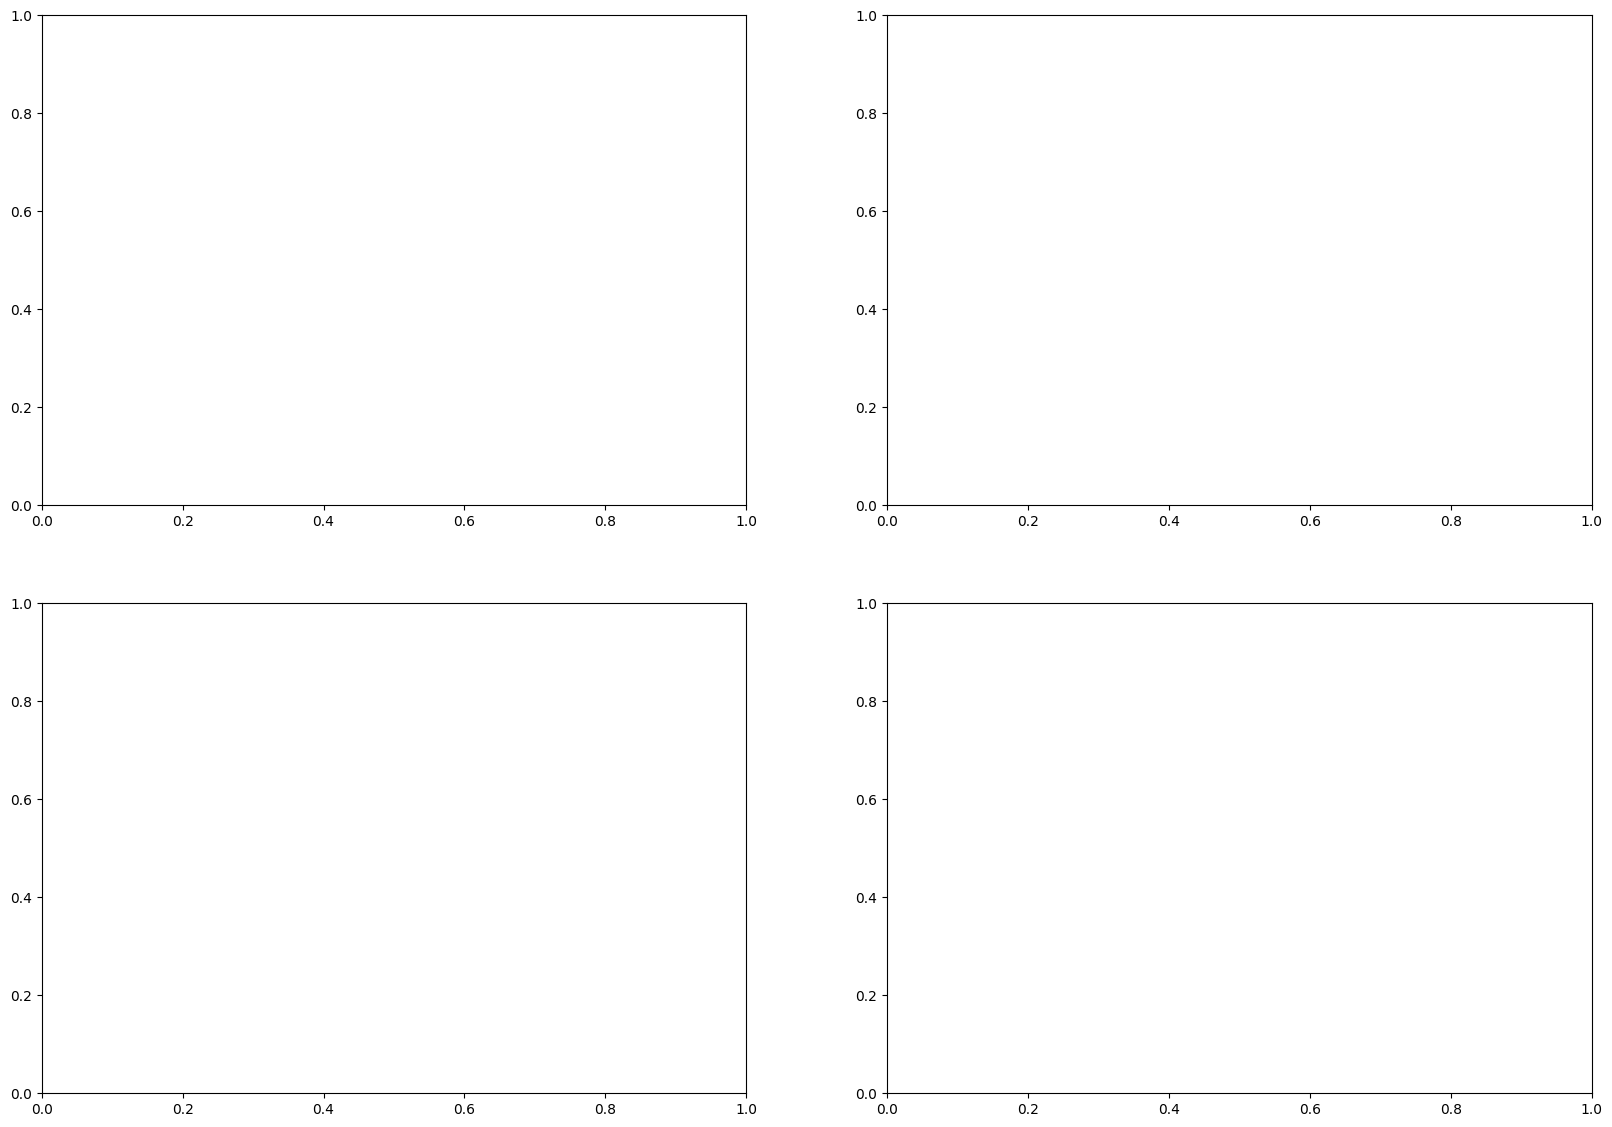

In [25]:
res, fig, ax = plot_persistence(X, y, max_dimension=3, max_edge_length=DistQ(0.25))